## AugurPy cell type priorization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# making sure plots & clusters are reproducible
np.random.seed(42)

In [2]:
## path variables
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/pertpy_results/'
fig_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'

In [3]:
## plotting params
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## treatment list
treatments = ['Nintedanib','GLPG1205','GLPG1690','Combo']

In [5]:
## empty list to hold the dataframes
dfs = []

In [6]:
for t in treatments:
    
    ## read augur results
    df = pd.read_csv(data_dir + f'augur_scores_{t}.csv', index_col = 'cell_type')
    
    ## rename the 'mean_augur_score' column to treatment name
    df = df.rename(columns={'mean_augur_score': t})
    
    ## drop unnecessary columns
    df = df[[t]]
    
    ## append the dataframe to the list
    dfs.append(df)

In [7]:
## concatenate dfs along the columns (axis=1)
augur_scores = pd.concat(dfs, axis=1)

In [8]:
augur_scores.head(5)

,Nintedanib,GLPG1205,GLPG1690,Combo
cell_type,,,,
Ciliated,0.628426,0.574352,0.643981,0.540880
Krt8+ ADI,0.500278,0.515741,0.541620,0.536944
AT2 activated,0.519074,0.509815,0.520509,0.484352
AT1,0.533519,0.540602,0.499398,0.507870
Lipofibroblasts,0.539120,0.521157,0.532917,0.509028


In [9]:
augur_scores.index

Index(['Ciliated', 'Krt8+ ADI', 'AT2 activated', 'AT1', 'Lipofibroblasts',
       'vSMCs', 'Cthrc1+ Myofibroblasts', 'Adventitial Fibroblasts',
       'Lipo/Myofibroblast Transition', 'Spp1+ Myofibroblasts', 'Pericytes',
       'General capillary EC', 'Vwa1+/Col15a1+ ectopic capillary EC',
       'Aerocyte capillary EC', 'Arterial EC', 'Venous EC', 'Lymphatic EC',
       'AM', 'Classical Monocytes', 'M2 Macrophages', 'Prg4+ IM', 'cDC2',
       'Lyve1-/Cd163- IM', 'pDC', 'Proliferating cDC1', 'cDC1',
       'Lyve1+/Cd163+ IM', 'Proliferating AM', 'Non-classical Monocytes',
       'Transitional Monocytes', 'NK cells', 'B cells', 'Th17 cells',
       'NK T cells', 'Cd8+ T cells', 'Cd4+ T cells', 'Th2 cells',
       'Cd4+/Cd8+ T cells', 'T reg cells', 'Proliferating T cells',
       'Eosinophils', 'Mature Neutrophils', 'Immature Neutrophils',
       'Intermediate Neutrophils', 'Proliferating capillary EC',
       'Intermediate Monocytes', 'IFN-primed Neutrophils', 'Basophils'],
      dtype

In [10]:
## top perturbed cell states
driver_states = ['T reg cells',
                 'Lipo/Myofibroblast Transition',
                 'Proliferating AM',
                 'Cthrc1+ Myofibroblasts',
                 'pDC',
                 'Krt8+ ADI',
                 'Vwa1+/Col15a1+ ectopic capillary EC',
                 'M2 Macrophages',
                 'Transitional Monocytes',
                 'Eosinophils',
                 'Proliferating T cells']

In [11]:
## subset augur scores to top perturbed cell states
augur_scores = augur_scores[augur_scores.index.isin(driver_states)]

In [12]:
## color palette for plotting
treatment_colors = ['#2E59A8', '#FFA500', '#C93333', '#20B2AA']

In [13]:
## sort df by nintedanib (which we see as reference for successful treatment)
augur_scores = augur_scores.sort_values(by=['Nintedanib'], ascending = False)

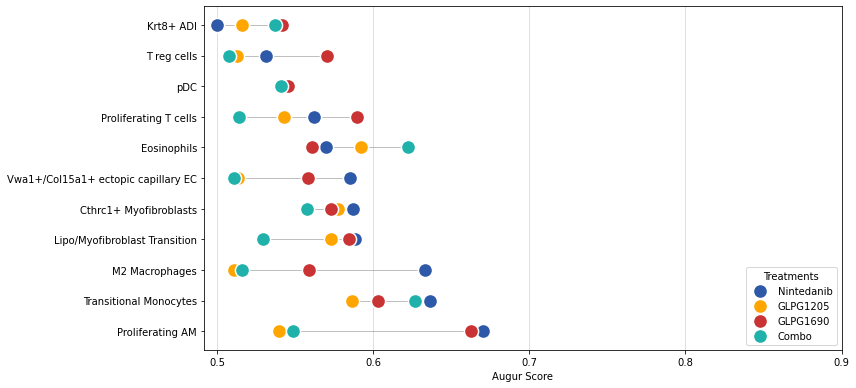

In [14]:
## plot size
plt.figure(figsize=(12, len(augur_scores) * 0.5))

## iterate through each cell type (row) in the df
for i, (cell_type, row) in enumerate(augur_scores.iterrows()):
    
    ## plot a horizontal line for the current cell type
    plt.hlines(y=i, xmin=row.min(), xmax=row.max(), color='gray', alpha=0.5, linewidth=1)
    
    ## plot lollipops (scatter points) for each treatment
    for j, (treatment, score) in enumerate(row.items()):
        plt.scatter(score, i, color = treatment_colors[j], label = treatment if i == 0 else "", edgecolors='white', linewidth=1.5, s=200, zorder=3)
        plt.plot([score, score], [i - 0.1, i + 0.1], color=treatment_colors[j], linewidth=2)

## set x and y-axis labels
plt.yticks(range(len(augur_scores)), augur_scores.index)
plt.xticks(ticks=np.arange(0.5, 0.9 + 0.1, 0.1))

## add x-axis label
plt.xlabel('Augur Score')

## add a legend and grid
plt.legend(title='Treatments', loc='lower right')
plt.grid(axis='x', alpha=0.5)

## show  plot
plt.tight_layout()

## save figure as PDF
plt.savefig(fig_dir + 'lollipop_augur_treatments.pdf')

## show plot
plt.show()

In [15]:
## plot again with seaborn for aesthetical reasons
cell_type_order = ['Proliferating AM',
                   'Transitional Monocytes',
                   'M2 Macrophages',
                   'Lipo/Myofibroblast Transition',
                   'Cthrc1+ Myofibroblasts',
                   'Vwa1+/Col15a1+ ectopic capillary EC',
                   'Eosinophils',
                   'Proliferating T cells',
                   'pDC',
                   'T reg cells',
                   'Krt8+ ADI'
                  ]

In [16]:
augur_scores

,Nintedanib,GLPG1205,GLPG1690,Combo
cell_type,,,,
Proliferating AM,0.670648,0.539676,0.662593,0.548796
Transitional Monocytes,0.636435,0.586759,0.603148,0.626574
M2 Macrophages,0.632963,0.510833,0.558843,0.515972
Lipo/Myofibroblast Transition,0.588704,0.573102,0.584259,0.529676
Cthrc1+ Myofibroblasts,0.586991,0.577731,0.573102,0.557824
Vwa1+/Col15a1+ ectopic capillary EC,0.585370,0.513704,0.558472,0.511204
Eosinophils,0.569815,0.592269,0.561111,0.622361
Proliferating T cells,0.562037,0.542778,0.589769,0.514074
pDC,0.543704,0.543750,0.545509,0.540741


In [17]:
## prepare the data in long format for seaborn
augur_scores_long = augur_scores.reset_index().melt(id_vars='cell_type', 
                                                    var_name='treatment', 
                                                    value_name='score')

In [18]:
augur_scores_long.rename(columns={'index': 'cell_type'}, inplace=True)

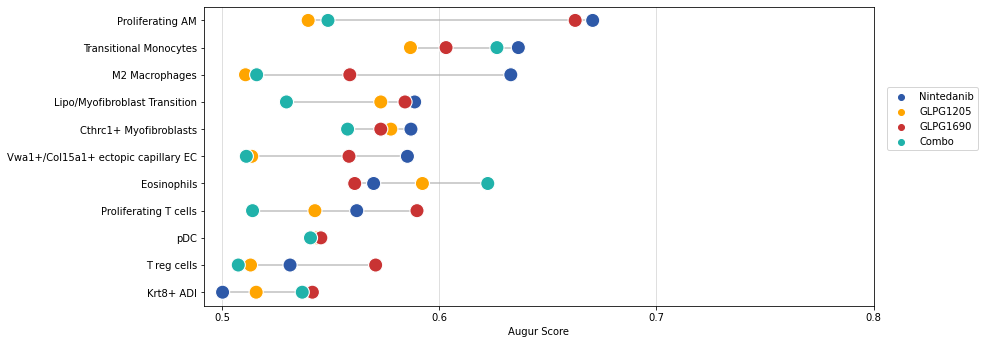

In [20]:
## plot size
plt.figure(figsize=(12, len(augur_scores) * 0.5))

## create the scatterplot with seaborn
sb.scatterplot(data=augur_scores_long,
               x='score',
               y='cell_type',
               hue='treatment',
               palette=treatment_colors,
               s=200,
               #edgecolor='white',
               #linewidth=1.5,
               zorder=3)

## plot horizontal lines for the cell types
for i, cell_type in enumerate(augur_scores.index):
    plt.hlines(y=i, xmin=augur_scores.loc[cell_type].min(), 
               xmax=augur_scores.loc[cell_type].max(), 
               color='gray', alpha=0.5, linewidth=1.5, zorder=1)

## set x and y-axis labels
plt.yticks(range(len(augur_scores)), augur_scores.index)
plt.xticks(ticks=np.arange(0.5, 0.75 + 0.1, 0.1))

## add x-axis label
plt.ylabel('')
plt.xlabel('Augur Score')
plt.legend(loc=(1.02, 0.52))

## add a legend and grid
plt.legend(title='Treatments', loc='lower right')
plt.grid(axis='x', alpha=0.5)

## add x-axis label
plt.ylabel('')
plt.xlabel('Augur Score')
plt.legend(loc=(1.02, 0.52))

## save the figure as a PDF
plt.savefig(fig_dir + 'lollipop_augur_treatments_harmonized.pdf')

## show the plot
plt.show()